# Barcelona — Listings: Exploration & Cleaning
**Input :** `../../Data/raw/Barcelona/listings.csv.gz`  
**Output:** `../../Data/interim/barcelona_listings_clean.parquet`

Runs the shared `clean_listings()` pipeline, applies city-specific outlier
decisions, and exports a clean Parquet file consumed by the analysis notebook.

In [1]:
# !pip install pyarrow wordcloud textblob  # run once if needed

In [2]:
import sys
sys.path.insert(0, "../..")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import f_oneway, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from airbnb_iip.data.cleaning import (
    clean_listings, missing_report,
    standardize_property_type, rate_bucket,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 200)

## 1 · Load raw data

In [3]:
l_df_raw = pd.read_csv(
    "../../Data/raw/Barcelona/listings.csv.gz",
    compression="gzip",
    low_memory=False,
)
print(f"Shape  : {l_df_raw.shape}")
print(f"Memory : {l_df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape  : (18177, 85)
Memory : 78.0 MB


## 2 · Initial exploration

In [4]:
l_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18177 entries, 0 to 18176
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            18177 non-null  int64  
 1   listing_url                                   18177 non-null  object 
 2   scrape_id                                     18177 non-null  int64  
 3   last_scraped                                  18177 non-null  object 
 4   source                                        18177 non-null  object 
 5   name                                          18177 non-null  object 
 6   description                                   17550 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   18177 non-null  object 
 9   host_id                                       18177 non-null 

In [5]:
display(l_df_raw.head())
display(l_df_raw.tail())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20251214012024,2025-12-14,city scrape,Huge flat for 8 people close to Sagrada Familia,"110m2 apartment to rent in Barcelona. Located in the Eixample district, near the Sagrada Familia. It has a small balcony where you can see the temple of Gaudi. Capacity for 8 people. <br /><br />L...",NaN,https://a0.muscache.com/pictures/13031453/413cdbfc_original.jpg,71615,https://www.airbnb.com/users/show/71615,1462508358342835057,https://www.airbnb.com/users/profile/1462508358342835057,Mireia,2010-01-19,15.0,10.0,14.0,11.0,"Barcelona, Spain","We are Mireia (47) & Maria (49), two multilingual entrepreneurs loving Barcelona and having big experience in the touristic market.\nAna and Beka from reservation department will attend you\nand f...",within an hour,95%,90%,f,https://a0.muscache.com/im/pictures/user/User/original/13242c7b-4fc1-415f-a5d7-6474d869a343.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User/original/13242c7b-4fc1-415f-a5d7-6474d869a343.jpeg?aki_policy=profile_x_medium,la Sagrada Família,39.0,43.0,"['email', 'phone']",t,t,NaN,la Sagrada Família,Eixample,41.40556,2.17262,Entire rental unit,Entire home/apt,8,2.0,2 baths,3.0,6.0,"[""Elevator"", ""Refrigerator"", ""Crib"", ""City skyline view"", ""Free washer \u2013 In unit"", ""Essentials"", ""Hangers"", ""Kitchen"", ""Pets allowed"", ""Heating"", ""Coffee maker"", ""Dishes and silverware"", ""Hai...",NaN,1,1125,1.0,4.0,999.0,999.0,2.9,999.0,NaN,t,20,50,74,115,2025-12-14,54,9,1,8,5,54,NaN,2013-05-27,2025-11-19,4.36,4.42,4.57,4.62,4.62,4.81,4.34,Spain - National registration number<br />ESFCTU000008058000039706000000000000000HUTB-002062349<br /><br />Barcelona - Regional registration number<br />HUTB-002062,t,24,24,0,0,0.35
1,2031134,https://www.airbnb.com/rooms/2031134,20251214012024,2025-12-14,city scrape,Sagrada Familia-auditorium. FREE WI-FI.,"Cheap apartment, 45 m2 with a license from the City of Barcelona, 2 bedrooms for a maximum of 4 people with TV, air conditioning and Wi-Fi. <br /> Perfect for enjoying your stay in Barcelona. Clos...",NaN,https://a0.muscache.com/pictures/30632356/cf2b8d52_original.jpg,9100900,https://www.airbnb.com/users/show/9100900,1462794940868112780,https://www.airbnb.com/users/profile/1462794940868112780,Miguel,2013-09-28,12.0,2.0,12.0,0.0,"Barcelona, Spain","Me llamo Miguel, y con mi hermana Carolina, gestionamos un apartamento de alquiler económico. \n\nMi propi

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
18172,1574656863638461043,https://www.airbnb.com/rooms/1574656863638461043,20251214012024,2025-12-14,city scrape,Habitación económica con wifi,"Simple room with a comfortable bed and closet. Shared apartment with a respectful atmosphere. Public transportation very close, ideal for moving quickly around the city.",NaN,https://a0.muscache.com/pictures/hosting/Hosting-1574656863638461043/original/63d0a7c0-3e7e-4d61-9c0c-330578807c63.jpeg,731296157,https://www.airbnb.com/users/show/731296157,1564548850394018347,https://www.airbnb.com/users/profile/1564548850394018347,Shirley Alisson,2025-11-27,0.0,0.0,0.0,0.0,"Madrid, Spain",NaN,within an hour,91%,100%,f,https://a0.muscache.com/im/pictures/user/User/original/81be16d7-9d6d-4ec3-a04f-b056935ebe4e.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User/original/81be16d7-9d6d-4ec3-a04f-b056935ebe4e.jpeg?aki_policy=profile_x_medium,NaN,13.0,14.0,"['email', 'phone']",t,t,NaN,la Dreta de l'Eixample,Eixample,41.386120,2.16913,Private room in rental unit,Private room,2,1.0,1 shared bath,1.0,0.0,"[""Carbon monoxide alarm"", ""Fire extinguisher"", ""Smoke alarm"", ""Wifi"", ""Kitchen""]",NaN,2,21,1.0,2.0,21.0,21.0,2.0,21.0,NaN,t,17,35,60,335,2025-12-14,0,0,0,8,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barcelona - Regional registration number<br />HUTB-282031<br /><br />Spain - National registration number<br />ESCFTU00003103400023548300800000000000000000000000480,t,5,1,4,0,NaN
18173,1574664158072287966,https://www.airbnb.com/rooms/1574664158072287966,20251214012024,2025-12-14,city scrape,Habitación básica pero confortable,"Basic but comfortable room in a quiet shared apartment. Perfect for practical travelers. Access to equipped kitchen, WiFi and nearby services.",NaN,https://a0.muscache.com/pictures/hosting/Hosting-1574664158072287966/original/3468c1cb-9cde-4c7c-858a-418e27a52851.jpeg,731296157,https://www.airbnb.com/users/show/731296157,1564548850394018347,https://www.airbnb.com/users/profile/1564548850394018347,Shirley Alisson,2025-11-27,0.0,0.0,0.0,0.0,"Madrid, Spain",NaN,within an hour,91%,100%,f,https://a0.muscache.com/im/pictures/user/User/original/81be16d7-9d6d-4ec3-a04f-b056935ebe4e.jpeg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/User/original/81be16d7-9d6d-4ec3-a04f-b056935ebe4e.jpeg?aki_policy=profile_x_medium,NaN,13.0,14.0,"['email', 'phone']",t,t,NaN,la Dreta de l'Eixample,Eixample,41.388040,2.16863,Private room in r

In [6]:
l_df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,18177.0,6.447131e+17,6.114387e+17,1.867400e+04,3.067338e+07,7.246708e+17,1.222431e+18,1.574761e+18
scrape_id,18177.0,2.025121e+13,0.000000e+00,2.025121e+13,2.025121e+13,2.025121e+13,2.025121e+13,2.025121e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,18177.0,2.095417e+08,2.166172e+08,3.073000e+03,1.178986e+07,1.310289e+08,3.621554e+08,7.320408e+08
host_profile_id,18177.0,1.467412e+18,9.983763e+15,1.462506e+18,1.462709e+18,1.465908e+18,1.469674e+18,1.568799e+18
hosts_time_as_user_years,18171.0,7.782841e+00,4.192749e+00,0.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01,1.700000e+01
hosts_time_as_user_months,18171.0,5.321336e+00,3.392591e+00,0.000000e+00,2.000000e+00,6.000000e+00,8.000000e+00,1.100000e+01
hosts_time_as_host_years,18171.0,7.028067e+00,4.247993e+00,0.000000e+00,3.000000e+00,7.000000e+00,1.100000e+01,1.400000e+01
hosts_time_as_host_months,18171.0,5.267459e+00,3.302758e+00,0.000000e+00,2.000000e+00,5.000000e+00,8.000000e+00,1.100000e+01
host_listings_count,18171.0,9.411216e+01,1.971339e+02,1.000000e+00,2.000000e+00,1.200000e+01,7.100000e+01,2.874000e+03


,missing_count,missing_percent
neighbourhood,18177,100.000000
estimated_revenue_l365d,18177,100.000000
neighborhood_overview,18177,100.000000
price,18177,100.000000
calendar_updated,18177,100.000000
host_neighbourhood,9791,53.864774
license,7163,39.406943
host_about,6558,36.078561
review_scores_checkin,5086,27.980415
review_scores_value,5085,27.974913


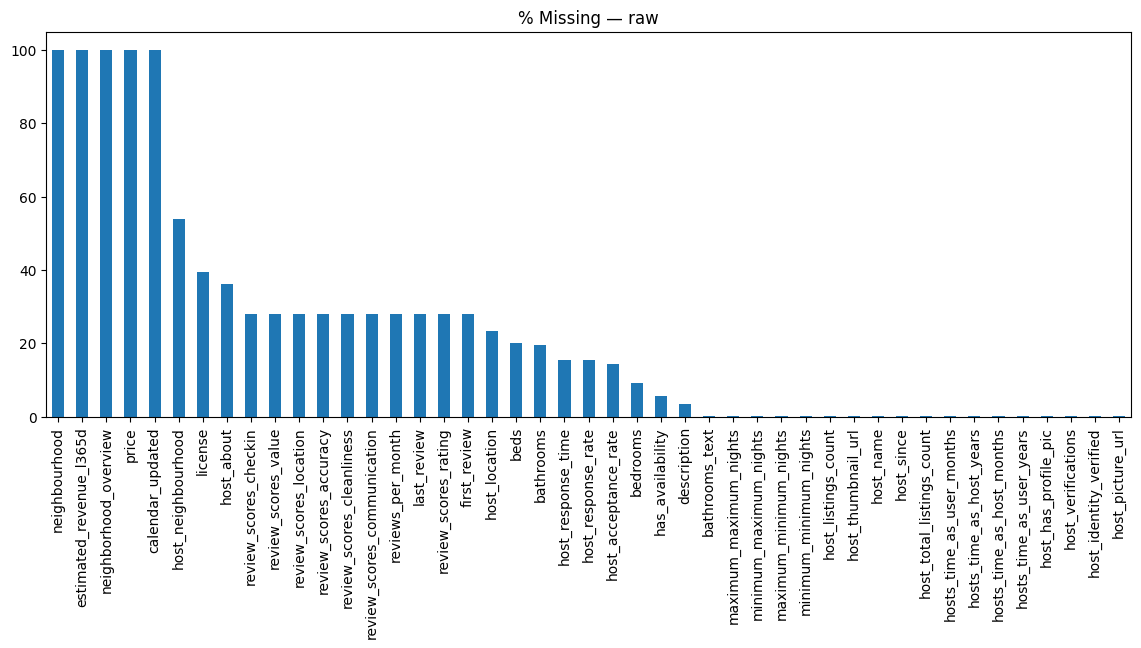

In [7]:
mr_raw = missing_report(l_df_raw)
mr_raw[mr_raw.missing_count > 0]["missing_percent"].plot(
    kind="bar", figsize=(14, 5), title="% Missing — raw"
)
display(mr_raw.head(20))

In [8]:
# Unique-value counts — categorical columns (skip long free-text)
_skip = {"description", "host_about", "neighborhood_overview", "amenities", "name"}
for col in l_df_raw.select_dtypes("object").columns.difference(_skip):
    print(f"\n{col}  ({l_df_raw[col].nunique()} unique)")
    print(l_df_raw[col].value_counts().head(6).to_string())


bathrooms_text  (38 unique)
bathrooms_text
1 bath            7377
2 baths           3831
1 shared bath     2343
1 private bath    1373
2 shared baths     708
1.5 baths          658

calendar_last_scraped  (2 unique)
calendar_last_scraped
2025-12-14    13310
2025-12-15     4867

first_review  (3818 unique)
first_review
2025-11-30    27
2025-11-23    26
2025-11-16    23
2025-07-31    21
2024-08-31    21
2025-05-31    21

has_availability  (1 unique)
has_availability
t    17153

host_acceptance_rate  (95 unique)
host_acceptance_rate
100%    4686
99%     2331
98%     1023
97%      680
28%      429
96%      418

host_has_profile_pic  (2 unique)
host_has_profile_pic
t    17600
f      571

host_identity_verified  (2 unique)
host_identity_verified
t    17295
f      876

host_is_superhost  (2 unique)
host_is_superhost
f    14000
t     4177

host_location  (384 unique)
host_location
Barcelona, Spain            12547
Madrid, Spain                 177
Bellaterra, Spain              75
Spain      

In [9]:
# Numeric ranges — flag obvious anomalies before cleaning
for col in l_df_raw.select_dtypes(include=["int64", "float64"]).columns:
    print(f"{col}: min={l_df_raw[col].min()}, max={l_df_raw[col].max()}")

id: min=18674, max=1574760542225568017
scrape_id: min=20251214012024, max=20251214012024
neighborhood_overview: min=nan, max=nan
host_id: min=3073, max=732040813
host_profile_id: min=1462506337038686997, max=1568799190352893081
hosts_time_as_user_years: min=0.0, max=17.0
hosts_time_as_user_months: min=0.0, max=11.0
hosts_time_as_host_years: min=0.0, max=14.0
hosts_time_as_host_months: min=0.0, max=11.0
host_listings_count: min=1.0, max=2874.0
host_total_listings_count: min=1.0, max=3807.0
neighbourhood: min=nan, max=nan
latitude: min=41.35067283884408, max=41.462243
longitude: min=2.09276, max=2.22183
accommodates: min=1, max=16
bathrooms: min=0.0, max=16.0
bedrooms: min=0.0, max=30.0
beds: min=0.0, max=127.0
price: min=nan, max=nan
minimum_nights: min=1, max=1124
maximum_nights: min=1, max=1125
minimum_minimum_nights: min=1.0, max=1124.0
maximum_minimum_nights: min=1.0, max=1124.0
minimum_maximum_nights: min=1.0, max=1125.0
maximum_maximum_nights: min=1.0, max=2147483647.0
minimum_nig

In [10]:
# Duplicate check
print("Full duplicates           :", l_df_raw.duplicated().sum())
print("Duplicate listing ids     :", l_df_raw.duplicated(subset=['id']).sum())

# duplicated everything except the id 
# Count rows where everything matches except id
cols_except_id = l_df_raw.columns.difference(['id']).tolist()
dup_except_id_count = l_df_raw.duplicated(subset=cols_except_id).sum()
print("Duplicated except ids:", dup_except_id_count)    

# same name + host + coords - indicates host owns whole building. 
print("Duplicate (name+host+coords):",
      l_df_raw.duplicated(subset=['name','host_id','latitude','longitude']).sum())


Full duplicates           : 0
Duplicate listing ids     : 0
Duplicated except ids: 0
Duplicate (name+host+coords): 188


## 3 · Cleaning pipeline

`clean_listings()` handles (in order):
1. Drop `calendar_updated`, `neighbourhood` (always useless)
2. Deduplicate ignoring `id` / `listing_url`
3. Parse dates, prices, rates, booleans
4. Normalise multi-host name separators → `&`
5. Reconcile `bathrooms` / `bathrooms_text` (fixes the `fillna("mode")` bug from legacy code)
6. Hierarchical imputation — host fields → price → beds/bedrooms
7. Review-score zeros / sentinel dates for never-reviewed listings
8. Temporal features: `host_tenure_years`, `days_since_*`, `review_span_years`
9. Engineered features: `property_type_std`, rate categories, `price_cat` (city-adaptive quartiles), `description_length`
10. Drop URL / thumbnail columns

In [11]:
l_df = clean_listings(l_df_raw)
print(f"After clean_listings(): {l_df.shape}")
l_df.info()

After clean_listings(): (0, 85)
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            0 non-null      int64         
 1   scrape_id                                     0 non-null      int64         
 2   last_scraped                                  0 non-null      datetime64[ns]
 3   source                                        0 non-null      object        
 4   name                                          0 non-null      object        
 5   description                                   0 non-null      object        
 6   neighborhood_overview                         0 non-null      float64       
 7   picture_url                                   0 non-null      object        
 8   host_id                                       0 non-nul

### City-specific decisions

Document outlier thresholds and the EDA evidence that justifies them.

In [12]:
# Barcelona-specific: extreme bed / bedroom counts found during EDA above
l_df = l_df[~((l_df['beds'] == 40) | (l_df['bedrooms'] == 25))]
print(f'After city-specific outlier removal: {l_df.shape}')

After city-specific outlier removal: (0, 85)


In [13]:
mr_clean = missing_report(l_df)
remaining = mr_clean[mr_clean.missing_count > 0]
if remaining.empty:
    print("No missing values remaining ✓")
else:
    display(remaining)
    remaining["missing_percent"].plot(
        kind="bar", figsize=(12, 4), title="% Missing — after cleaning"
    )

No missing values remaining ✓


In [14]:
# Confirm final dtypes and feature set
l_df.info()
print("\nEngineered columns added:")
new_cols = set(l_df.columns) - set(l_df_raw.columns)
print(sorted(new_cols))

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            0 non-null      int64         
 1   scrape_id                                     0 non-null      int64         
 2   last_scraped                                  0 non-null      datetime64[ns]
 3   source                                        0 non-null      object        
 4   name                                          0 non-null      object        
 5   description                                   0 non-null      object        
 6   neighborhood_overview                         0 non-null      float64       
 7   picture_url                                   0 non-null      object        
 8   host_id                                       0 non-null      int64         
 9   host_

## 4 · Export cleaned parquet

Output: `../../Data/interim/barcelona_listings_clean.parquet`

In [15]:
import pathlib

out_path = pathlib.Path("../../Data/interim/barcelona_listings_clean.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

l_df.to_parquet(out_path, index=False, engine="pyarrow")

print(f"Saved {l_df.shape[0]:,} rows × {l_df.shape[1]} cols → {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved 0 rows × 85 cols → ../../Data/interim/barcelona_listings_clean.parquet
File size: 0.0 MB
